In [1]:
%load_ext autoreload
%autoreload 2

import logging

from evilflowers_books_digitalizer import BookContext, BookSource, LocalCache, Pipeline, load_settings

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
for noisy in ("httpx", "ocrmypdf", "fontTools", "pikepdf"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

settings = load_settings()
cache = LocalCache(settings.cache_dir)

## Pick a book

Books are big (~24 MB/frame, up to ~13 GB) — default to the **smallest non-empty book** from the cached inventory (run notebook 01 first). Override `SOURCE_KEY` / `BOOK_ID` to experiment with a specific one.

In [2]:
SOURCE_KEY, BOOK_ID = None, None  # override here to pick a specific book

if BOOK_ID is None:
    # smallest non-empty book across all cached inventories (see notebook 01)
    candidates = [
        book
        for key in settings.sources
        if (stats := cache.load_stats(key)) is not None
        for book in stats.books
        if book.n_pages > 0
    ]
    if not candidates:
        raise RuntimeError("no cached stats — run notebook 01 first or set SOURCE_KEY/BOOK_ID manually")
    smallest = min(candidates, key=lambda book: book.total_bytes)
    SOURCE_KEY, BOOK_ID = smallest.source, smallest.book_id

source = BookSource(settings.sources[SOURCE_KEY])
book = source.get_book(BOOK_ID)
print(f"{SOURCE_KEY}/{BOOK_ID}: {book.n_pages} frames, {book.total_bytes / 1e6:.1f} MB")

fad/CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV: 21 frames, 717.1 MB


In [3]:
tiffs = source.download_book(book, cache.book_dir(SOURCE_KEY, BOOK_ID))
print(f"{len(tiffs)} frames in {tiffs[0].parent}")

CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV:   0%|          | 0/21 [00:00<?, ?page/s]

21 frames in /Users/jdubec/Projects/EvilFlowers/evilflowers-books-digitalizer/.cache/scans/fad/CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV


## Inspect the raw frames

The faculty scans are **two-page spreads on a black scanner bed** — uncompressed RGB @ 300 DPI. The preprocess step turns each frame into two clean single pages.

In [4]:
from PIL import Image

for path in tiffs[:3]:
    with Image.open(path) as img:
        print(
            f"{path.name}: {img.size[0]}x{img.size[1]}px, mode={img.mode}, "
            f"dpi={img.info.get('dpi')}, {path.stat().st_size / 1e6:.2f} MB"
        )

OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV_p0000.tif: 3777x3012px, mode=RGB, dpi=(300.0, 300.0), 34.15 MB
OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV_p0001.tif: 3777x3012px, mode=RGB, dpi=(300.0, 300.0), 34.15 MB
OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV_p0002.tif: 3777x3012px, mode=RGB, dpi=(300.0, 300.0), 34.15 MB


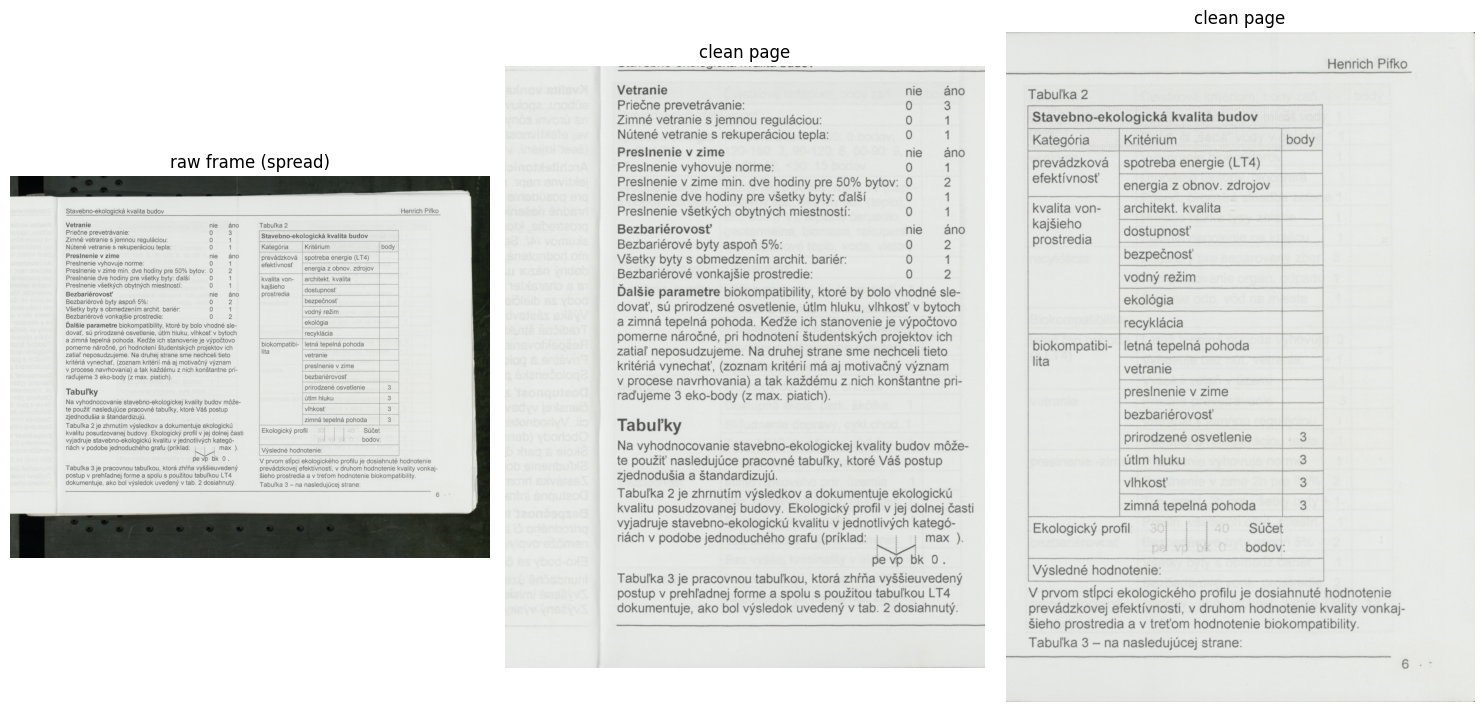

In [5]:
import matplotlib.pyplot as plt

from evilflowers_books_digitalizer.imaging import deskew, load_bgr, split_pages

frame = load_bgr(tiffs[min(5, len(tiffs) - 1)])
pages = [deskew(page)[0] for page in split_pages(frame)]

fig, axes = plt.subplots(1, 1 + len(pages), figsize=(15, 7))
axes[0].imshow(frame[:, :, ::-1]); axes[0].set_title("raw frame (spread)")
for ax, page in zip(axes[1:], pages):
    ax.imshow(page[:, :, ::-1]); ax.set_title("clean page")
for ax in axes:
    ax.axis("off")
fig.tight_layout()

## Run the standard pipeline

This composition is what batch processing will use. Settings come from the notebook 03 experiments.

In [6]:
from evilflowers_books_digitalizer.pipeline.steps import (
    AssemblePdf,
    DownloadBook,
    EnrichPdfMetadata,
    OcrPdf,
    PreprocessScans,
)

pipeline = Pipeline(
    [
        DownloadBook(source, cache),
        PreprocessScans(split=True, do_deskew=True, color_mode="auto"),
        AssemblePdf(),
        OcrPdf(language=settings.ocr_language, optimize=2, jobs=settings.ocr_jobs),
        EnrichPdfMetadata(),
    ]
)
pipeline

Pipeline(download -> preprocess -> assemble -> ocr -> enrich)

In [7]:
ctx = BookContext(
    source=SOURCE_KEY,
    book_id=BOOK_ID,
    work_dir=cache.book_dir(SOURCE_KEY, BOOK_ID),
    output_dir=settings.output_dir / SOURCE_KEY,
)
ctx = pipeline.run(ctx)

print("artifacts:")
for name, path in ctx.artifacts.items():
    print(f"  {name:8s} {path.name} ({path.stat().st_size / 1e6:.1f} MB)")
print("metadata:", ctx.metadata)

INFO evilflowers_books_digitalizer.pipeline.base: pipeline start: fad_CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV (5 steps)


CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV:   0%|          | 0/21 [00:00<?, ?page/s]

INFO evilflowers_books_digitalizer.pipeline.base: step download         done in    0.1s (fad_CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV)
INFO evilflowers_books_digitalizer.pipeline.steps.preprocess: fad_CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV: 21 frames -> 41 pages (20 spreads split, 1 color pages kept)
INFO evilflowers_books_digitalizer.pipeline.base: step preprocess       done in   11.7s (fad_CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV)
INFO evilflowers_books_digitalizer.pipeline.base: step assemble         done in    2.1s (fad_CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV)
WARNING ocrmypdf.subprocess: 
The program 'jbig2' could not be executed or was not found on your
system PATH.  This program is recommended when using the --optimize {2,3} arguments,
but not required, so we will proceed.  For best results, install the program.

WARNING ocrmypdf.builtin_plugins.ghostscript: Ghostscript 10.7.0 contains JPEG encoding errors that may corrupt images. OCRmyPDF will att

artifacts:
  raw_pdf  fad_CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV_raw.pdf (93.5 MB)
  pdf      fad_CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV.pdf (9.4 MB)
  text     fad_CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV.txt (0.0 MB)
metadata: {'n_frames': 21, 'n_pages': 41, 'n_pdf_pages': 41, 'n_text_chars': 42947}


In [8]:
# Sanity-check the recognized Slovak text (diacritics: á č ď é í ĺ ľ ň ó ô ŕ š ť ú ý ž)
text = ctx.artifacts["text"].read_text(errors="ignore")
print(f"{len(text)} characters of OCR text\n")
print(text[2000:3500])

42947 characters of OCR text

ešenia stavby, s kvalitou jej obvodového plášťa,

s použitým vykurovacím systémom a využívanými energetic-

Henrich Pifko

kými zdrojmi (aj z hľadiska obmedzovanie emisií CO»

a čerpania neobnoviteľných zdrojov).

Kvalita (vonkajšieho) prostredia je posudzovaná ako
architektonická a urbanistická kvalita vnímaná užívateľmi /2/,
ako ekologická kvalita (ekologická stabilita, ochrana prírodných
hodnôt) či z hľadiska sociologického (bezpečnosť prostredia,
identita, prístupnosť vybavenosti).

Biokompatibilita je tu chápaná ako hygienická kvalita
vnútorného prostredia, priraďujeme k nej bezbariérovosť.

K uvedeným kategóriám priraďujeme vybrané kritériá (či
subkategórie zahíňajúce vplyv viacerých kritérií). Tieto kritériá
sú vyberané tak, aby bolo možné posúdiť ich a porovnať ich

s vybraným štandardom. Pre vyjadrenie stavebno-ekologickej
kvality budov použijeme „eko-body“, počet možných bodov pre
jednotlivé kategórie a kritériá bol objektivizovaný expertným

a 

---
**Next:** `03_transformation_lab.ipynb` — tune the TIFF → PDF/A transformation (spread splitting, unpaper cleaning, compression/quality trade-offs, OCR confidence).

**Later:** batch runner over all 880 books; classification & embeddings pipelines on the OCR text.